# 202235203 고수호
# **6week - abalone.csv 데이터에 대한 DL_Regression**

# **# 라이브러리 임포트**

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

# **# 데이터 세트 불러오기**

In [61]:
path = '/content/drive/MyDrive/Colab Notebooks/6week/abalone.csv'
df = pd.read_csv(path)
df

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...,...
4172,4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


# **# 결측치 확인**

In [62]:
df.isnull().sum()

,0
id,0
Sex,0
Length,0
Diameter,0
Height,0
Whole_weight,0
Shucked_weight,0
Viscera_weight,0
Shell_weight,0
Rings,0


# **# 'Rings' 컬럼 개수 확인**

In [63]:
df['Rings'].value_counts()

,count
Rings,
9,689
10,634
8,568
11,487
7,391
12,267
6,259
13,203
14,126


# **# 라벨 인코딩 및 상관관계 확인**

<Axes: >

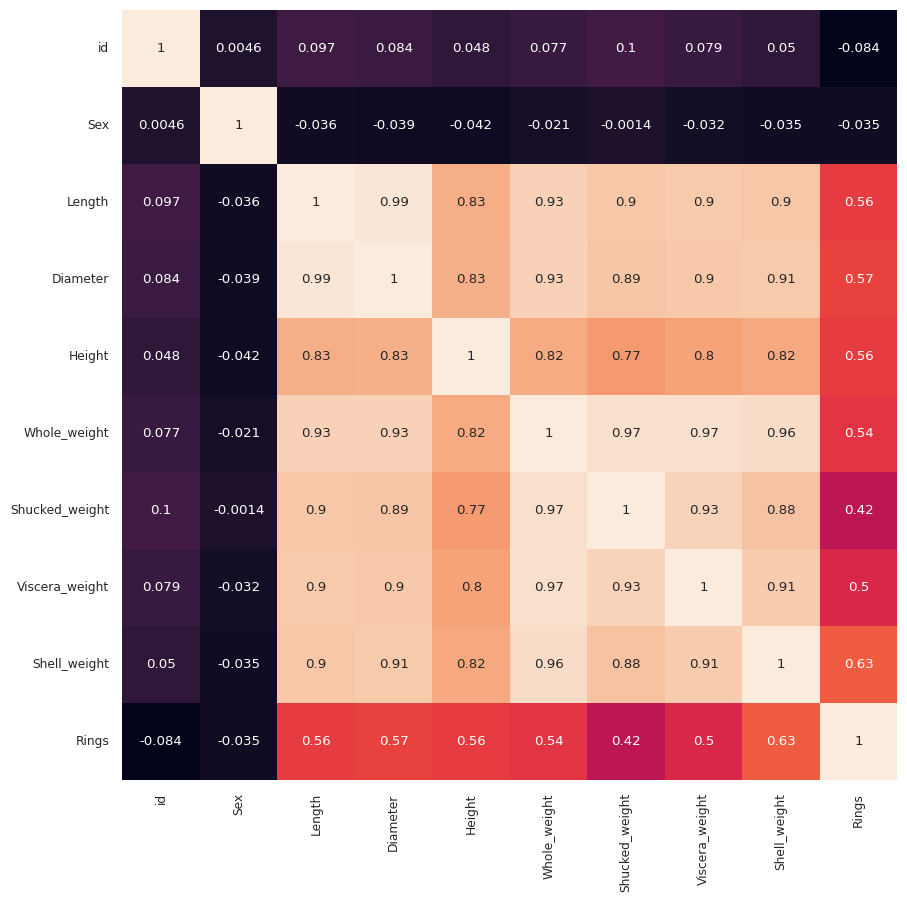

In [64]:
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

df_corr = df.corr()
plt.figure(figsize=(10,10))
sns.set(font_scale = 0.8)
sns.heatmap(df_corr, annot=True, cbar=False)

# **# 종속변수(Y) 설정**

In [65]:
Y=df['Rings']

# **# 독립변수(X) 설정 및 Numpy 배열 변환**

In [66]:
X=df.drop(['Rings', 'Sex', 'id'], axis=1)
X = X.values

# **# 데이터셋 분리 (Training & Test Set)**

In [67]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

# **# 딥러닝 모델 구성 및 학습**

In [68]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD,Adam


model = Sequential()

model.add(Dense(8,input_shape=(X.shape[1],),activation='relu'))
model.add(Dense(30,activation='relu'))
model.add(Dense(30,activation='relu'))
model.add(Dense(1))

model.compile(optimizer = 'adam', loss = 'mse', metrics = ['mse'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 8)              │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 30)             │           270 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,295 (5.06 KB)

 Trainable params: 1,295 (5.06 KB)

 Non-trainable params: 0 (0.00 B)

# **# 모델 학습 및 예측**

In [69]:
N_EPOCHS = 50

history=model.fit(x=X_train, y=y_train, epochs=N_EPOCHS, batch_size=32,validation_data= (X_test,y_test))
y_pred = model.predict(X_test)

Epoch 1/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 76.9571 - mse: 76.9571 - val_loss: 23.5650 - val_mse: 23.5650
Epoch 2/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 9.1071 - mse: 9.1071 - val_loss: 7.4737 - val_mse: 7.4737
Epoch 3/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.3712 - mse: 7.3712 - val_loss: 6.8385 - val_mse: 6.8385
Epoch 4/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.6369 - mse: 6.6369 - val_loss: 6.5266 - val_mse: 6.5266
Epoch 5/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 6.4224 - mse: 6.4224 - val_loss: 6.4277 - val_mse: 6.4277
Epoch 6/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 6.2909 - mse: 6.2909 - val_loss: 6.3477 - val_mse: 6.3477
Epoch 7/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6.2023 - mse: 6.2023 - val_loss: 6.2728 - val_mse: 6.2728
Epoch 8/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.1237 - mse: 6.1237 - val_loss: 6.1947 - val_mse: 6.1947
Epoch 9/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/st

# **# 손실 지표 시각화**

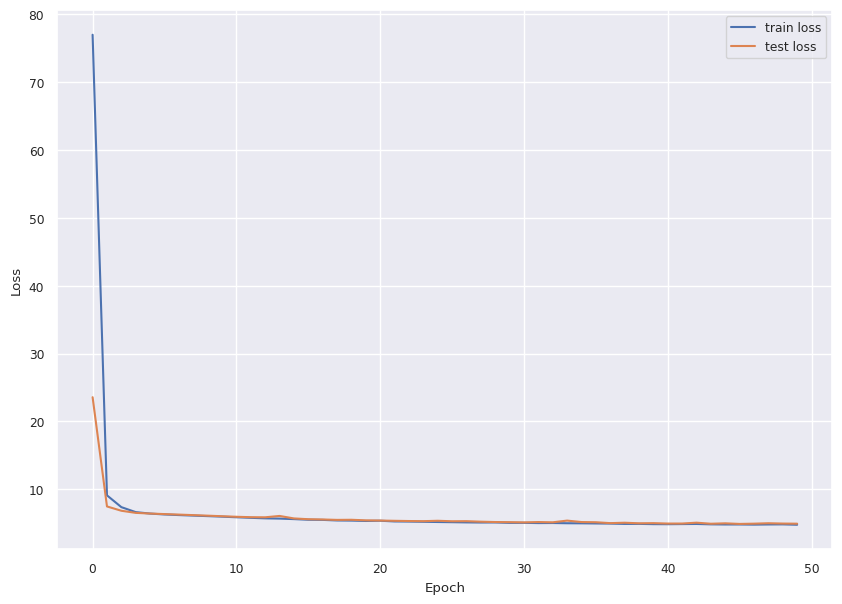

In [70]:
plt.figure(figsize=(10,7))
plt.plot(range(N_EPOCHS), history.history['loss'], label='train loss')
plt.plot(range(N_EPOCHS), history.history['val_loss'], label='test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# **# 모델 평가 수행**

In [71]:
model.evaluate(X_test, y_test)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.9329 - mse: 4.9329


[4.932948589324951, 4.932948589324951]